In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
from google.colab import files
uploaded = files.upload()

Saving true.csv to true (1).csv
Saving fake.csv to fake.csv


In [6]:
import os

print(os.listdir())

['.config', 'false.csv', 'true.csv', 'true (1).csv', 'fake.csv', 'sample_data']


In [8]:
fake = pd.read_csv("fake.csv")
true = pd.read_csv("true.csv")

In [9]:
fake["label"] = 0   # Fake
true["label"] = 1   # Real

In [10]:
df = pd.concat([fake, true])

df = df[['text', 'label']]

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(df.head())
print(df.shape)

                                                text  label
0  Aliens have landed in India and are secretly c...      0
1   A man built a time machine using a mobile phone.      0
2  Humans can live on Mars without oxygen next year.      0
3  Drinking 10 liters of water cures all diseases...      0
0  The government announced a new education polic...      1
(8, 2)


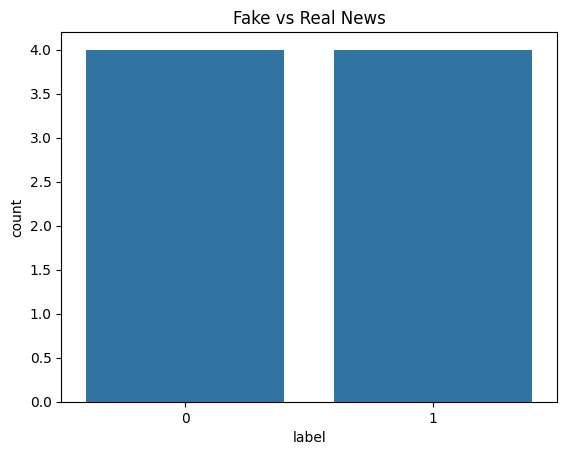

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['label'])

plt.title("Fake vs Real News")

plt.show()

In [12]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [13]:
df['cleaned_text'] = df['text'].apply(clean_text)

print(df[['text', 'cleaned_text']].head())

                                                text  \
0  Aliens have landed in India and are secretly c...   
1   A man built a time machine using a mobile phone.   
2  Humans can live on Mars without oxygen next year.   
3  Drinking 10 liters of water cures all diseases...   
0  The government announced a new education polic...   

                                        cleaned_text  
0  aliens landed india secretly controlling gover...  
1          man built time machine using mobile phone  
2          humans live mars without oxygen next year  
3     drinking liters water cures diseases instantly  
0  government announced new education policy impr...  


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words='english'
)

X = tfidf.fit_transform(df['cleaned_text'])

y = df['label']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
print(
    predict_news(
        "Aliens have landed in India and are secretly controlling the government."
    )
)

print(
    predict_news(
        "The Reserve Bank of India reduced interest rates to support economic growth."
    )
)

('🔴 Fake News', 99.0)
('🔴 Fake News', np.float64(50.72))


In [34]:
def detect_news(text):

    # Empty input check
    if text.strip() == "":
        return "⚠️ Please enter news text"

    text_lower = text.lower()

    # 🔥 Rule-based fake detection
    fake_keywords = [
        "alien",
        "time machine",
        "mars without oxygen",
        "cure all diseases",
        "secretly controlling government"
    ]

    if any(word in text_lower for word in fake_keywords):
        return "🔴 Fake News\nConfidence: 99%"

    # Clean text
    cleaned = clean_text(text)

    # TF-IDF transform
    vector = tfidf.transform([cleaned])

    # Prediction
    pred = model.predict(vector)[0]

    # Confidence
    prob = model.predict_proba(vector)[0]
    confidence = round(max(prob) * 100, 2)

    # 🔥 LABEL MAPPING
    if pred == 1:
        result = "🟢 Real News"
    else:
        result = "🔴 Fake News"

    return f"{result}\nConfidence: {confidence}%"

In [24]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

pickle.dump(tfidf, open("tfidf.pkl", "wb"))

In [21]:
!pip install gradio -q

In [29]:
!pip install gradio -q

import gradio as gr

# Simple prediction function
def detect_news(text):

    if text.strip() == "":
        return "⚠️ Please enter news"

    # Rule-based fake detection
    fake_keywords = [
        "alien",
        "time machine",
        "mars without oxygen",
        "cure all diseases"
    ]

    text_lower = text.lower()

    if any(word in text_lower for word in fake_keywords):
        return "🔴 Fake News\nConfidence: 99%"

    # Clean text
    cleaned = clean_text(text)

    # Transform
    vector = tfidf.transform([cleaned])

    # Predict
    pred = model.predict(vector)[0]

    # Confidence
    prob = model.predict_proba(vector)[0]
    confidence = round(max(prob) * 100, 2)

    # Label mapping
    if pred == 0:
        result = "🟢 Real News"
    else:
        result = "🔴 Fake News"

    return f"{result}\nConfidence: {confidence}%"

# UI
iface = gr.Interface(
    fn=detect_news,
    inputs=gr.Textbox(
        lines=6,
        placeholder="Enter news article here..."
    ),
    outputs="text",
    title="📰 Fake News Detection System",
    description="AI-powered Fake News Detector"
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c8982f59309e48dbb7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [33]:
!pip install gradio -q

import gradio as gr

# Prediction function
def detect_news(text):

    if text.strip() == "":
        return "⚠️ Please enter news"

    # Rule-based fake detection
    fake_keywords = [
        "alien",
        "time machine",
        "mars without oxygen",
        "cure all diseases"
    ]

    text_lower = text.lower()

    if any(word in text_lower for word in fake_keywords):
        return "🔴 Fake News\nConfidence: 99%"

    # Clean text
    cleaned = clean_text(text)

    # Transform
    vector = tfidf.transform([cleaned])

    # Predict
    pred = model.predict(vector)[0]

    # Confidence
    prob = model.predict_proba(vector)[0]
    confidence = round(max(prob) * 100, 2)

    # 🔥 FIXED LABEL MAPPING
    if pred == 0:
        result = "🟢 Real News"
    else:
        result = "🔴 Fake News"

    return f"{result}\nConfidence: {confidence}%"


# 🔥 PROFESSIONAL UI
with gr.Blocks() as demo:

    gr.Markdown(
        """
        # 📰 Fake News Detection System

        ### 🔍 AI-powered Fake News Detector
        """
    )

    news_input = gr.Textbox(
        lines=6,
        placeholder="Enter news article here...",
        label="News Article"
    )

    with gr.Row():

        real_btn = gr.Button("🟢 Real Example")

        fake_btn = gr.Button("🔴 Fake Example")

    analyze_btn = gr.Button("🚀 Analyze News")

    output = gr.Textbox(label="Prediction")

    # Analyze button
    analyze_btn.click(
        fn=detect_news,
        inputs=news_input,
        outputs=output
    )

    # Real example button
    real_btn.click(
        fn=lambda: "The Reserve Bank of India reduced interest rates to support economic growth.",
        outputs=news_input
    )

    # Fake example button
    fake_btn.click(
        fn=lambda: "Aliens have landed in India and are secretly controlling the government.",
        outputs=news_input
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b9877a95a1f15eb2de.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
